In [1]:
import pandas as pd

# Load the final integrated dataset
file_path = "/content/Business_Analyst_Integrated_Dataset.xlsx"

df = pd.read_excel(file_path)

# Display basic information
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (4440, 11)

Columns:
['job_link', 'job_title', 'company', 'job_location', 'search_city', 'search_country', 'job_level', 'job_type', 'first_seen', 'job_skills', 'job_summary']

First 5 rows:


,job_link,job_title,company,job_location,search_city,search_country,job_level,job_type,first_seen,job_skills,job_summary
0,https://www.linkedin.com/jobs/view/secret-clea...,Secret cleared Business Analyst,Latitude Inc,"Crystal City, VA",Virginia,United States,Mid senior,Onsite,2024-01-13,"Microsoft Office 365, Microsoft Teams, SharePo...",The work schedule is 8 hours a day Monday - Fr...
1,https://www.linkedin.com/jobs/view/business-an...,Business Analyst (11076-1),RAPS Consulting Inc,"Columbia, SC",Columbia,United States,Mid senior,Onsite,2024-01-14,"Technical Writing, Information Security, Micro...",Department of Health and Human Services\n1 - R...
2,https://www.linkedin.com/jobs/view/principal-b...,Principal Business Analyst,NextEra Energy Services,"Riviera Beach, FL",Palm Springs,United States,Mid senior,Onsite,2024-01-14,"NEER, FPL, Reliability reporting, GADS applica...",Requisition ID: 77096\nFlorida Power & Light C...
3,https://www.linkedin.com/jobs/view/salesforce-...,SalesForce Business Analyst,Treys Pte. Ltd.,"Washington, DC",Clinton,United States,Mid senior,Onsite,2024-01-17,"Business Analysis, Business Requirements Gathe...",Title:\nSalesForce Business Analyst\nLocation:...
4,https://www.linkedin.com/jobs/view/pricing-tra...,Pricing Transparency Analyst/CTrax Senior Busi...,CereCore,"Brentwood, TN",Nashville,United States,Mid senior,Onsite,2024-01-13,"Pricing Transparency Analyst, Data analysis, Q...",Classification: Contract\nContract Length: 12 ...


In [2]:
# Basic validation
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate job_links:", df["job_link"].duplicated().sum())

Number of rows: 4440
Number of columns: 11

Missing values:
job_link          0
job_title         0
company           0
job_location      0
search_city       0
search_country    0
job_level         0
job_type          0
first_seen        0
job_skills        0
job_summary       0
dtype: int64

Duplicate rows: 0
Duplicate job_links: 0


### **RQ1 Job characteristics and demand based analysis**

In [3]:
# Top 15 Business Analyst job titles

top_titles = (
    df["job_title"]
    .value_counts()
    .head(15)
    .reset_index()
)

top_titles.columns = ["job_title", "job_count"]

display(top_titles)

,job_title,job_count
0,Business Analyst,988
1,Senior Business Analyst,205
2,JDE Business Analyst (Supply Chain),156
3,JD Edwards Business Analyst,141
4,IT Business Analyst,64
5,Technical Business Analyst,60
6,Business Analyst II,49
7,Business Analyst III,36
8,Sr. Business Analyst,29
9,Business Analyst I,28


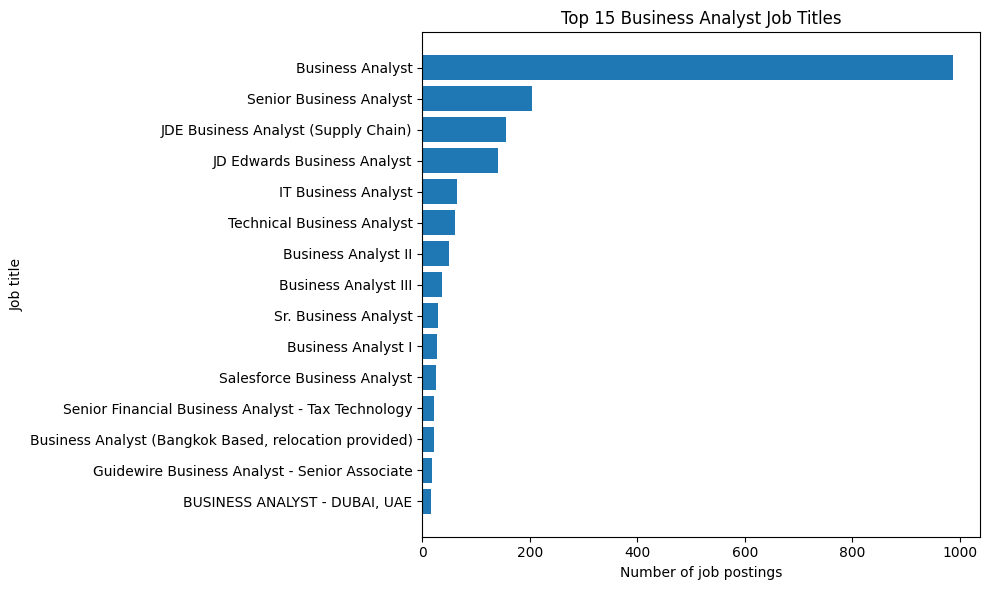

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top_titles["job_title"][::-1],
    top_titles["job_count"][::-1]
)

plt.xlabel("Number of job postings")
plt.ylabel("Job title")
plt.title("Top 15 Business Analyst Job Titles")

plt.tight_layout()
plt.show()

**Top 15 companies**

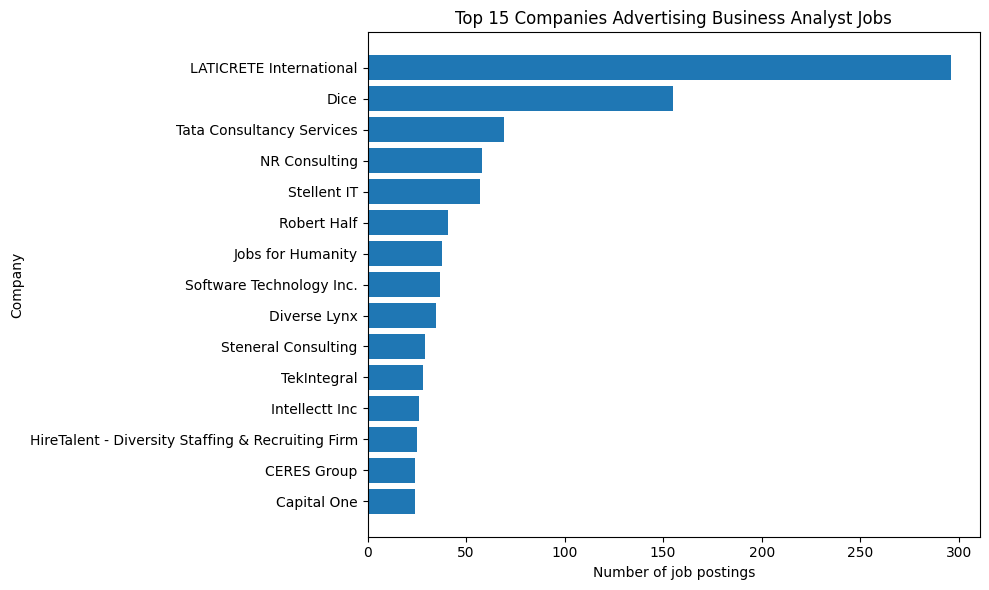

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top_companies["company"][::-1],
    top_companies["job_count"][::-1]
)

plt.xlabel("Number of job postings")
plt.ylabel("Company")
plt.title("Top 15 Companies Advertising Business Analyst Jobs")

plt.tight_layout()
plt.show()

**Job Level Distribution**

In [7]:
# Job level distribution

job_level = (
    df["job_level"]
    .value_counts()
    .reset_index()
)

job_level.columns = ["job_level", "job_count"]

display(job_level)

,job_level,job_count
0,Mid senior,3926
1,Associate,514


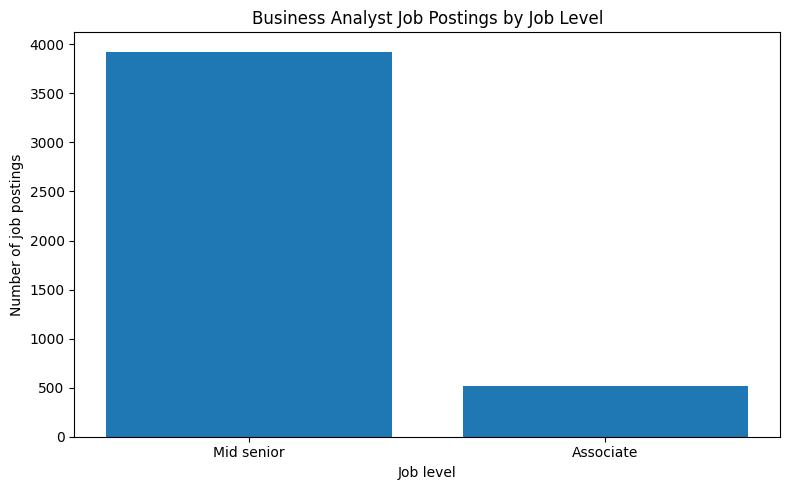

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    job_level["job_level"],
    job_level["job_count"]
)

plt.xlabel("Job level")
plt.ylabel("Number of job postings")
plt.title("Business Analyst Job Postings by Job Level")

plt.tight_layout()
plt.show()

**ANALYSING BY JOB TITLES**

In [10]:
# Examine all unique Business Analyst job titles

title_list = (
    df["job_title"]
    .value_counts()
    .reset_index()
)

title_list.columns = ["job_title", "job_count"]

print("Number of unique job titles:", len(title_list))

display(title_list.head(50))

Number of unique job titles: 1986


,job_title,job_count
0,Business Analyst,988
1,Senior Business Analyst,205
2,JDE Business Analyst (Supply Chain),156
3,JD Edwards Business Analyst,141
4,IT Business Analyst,64
5,Technical Business Analyst,60
6,Business Analyst II,49
7,Business Analyst III,36
8,Sr. Business Analyst,29
9,Business Analyst I,28


In [11]:
# Analyse concentration of Business Analyst job titles

total_jobs = len(df)

top_5_count = df["job_title"].value_counts().head(5).sum()
top_10_count = df["job_title"].value_counts().head(10).sum()
top_15_count = df["job_title"].value_counts().head(15).sum()
top_20_count = df["job_title"].value_counts().head(20).sum()

concentration = pd.DataFrame({
    "Title group": [
        "Top 5 titles",
        "Top 10 titles",
        "Top 15 titles",
        "Top 20 titles"
    ],
    "Job postings": [
        top_5_count,
        top_10_count,
        top_15_count,
        top_20_count
    ],
    "Percentage of all jobs": [
        top_5_count / total_jobs * 100,
        top_10_count / total_jobs * 100,
        top_15_count / total_jobs * 100,
        top_20_count / total_jobs * 100
    ]
})

display(concentration)

,Title group,Job postings,Percentage of all jobs
0,Top 5 titles,1554,35.000000
1,Top 10 titles,1756,39.549550
2,Top 15 titles,1859,41.869369
3,Top 20 titles,1938,43.648649


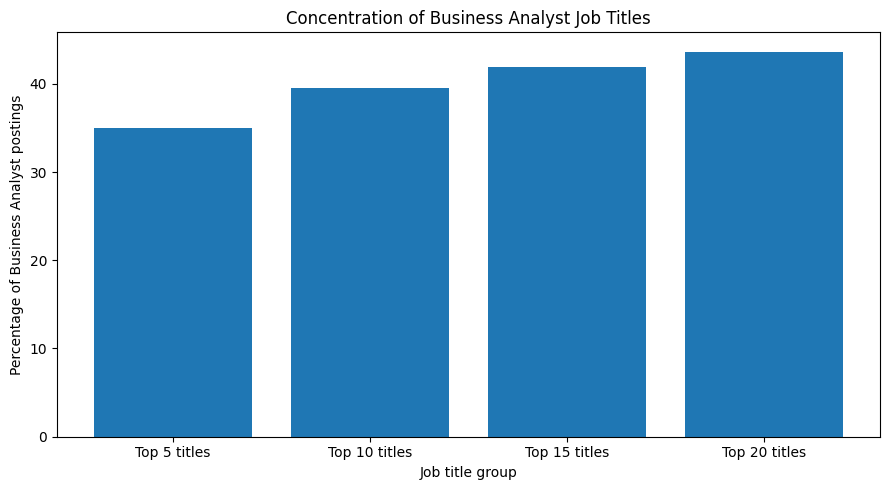

In [12]:
plt.figure(figsize=(9, 5))

plt.bar(
    concentration["Title group"],
    concentration["Percentage of all jobs"]
)

plt.xlabel("Job title group")
plt.ylabel("Percentage of Business Analyst postings")
plt.title("Concentration of Business Analyst Job Titles")

plt.tight_layout()
plt.show()

In [13]:
# Analyse concentration of Business Analyst job postings by company

company_counts = df["company"].value_counts()

total_jobs = len(df)

top_5_companies = company_counts.head(5).sum()
top_10_companies = company_counts.head(10).sum()
top_15_companies = company_counts.head(15).sum()
top_20_companies = company_counts.head(20).sum()

company_concentration = pd.DataFrame({
    "Company group": [
        "Top 5 companies",
        "Top 10 companies",
        "Top 15 companies",
        "Top 20 companies"
    ],
    "Job postings": [
        top_5_companies,
        top_10_companies,
        top_15_companies,
        top_20_companies
    ],
    "Percentage of all jobs": [
        top_5_companies / total_jobs * 100,
        top_10_companies / total_jobs * 100,
        top_15_companies / total_jobs * 100,
        top_20_companies / total_jobs * 100
    ]
})

display(company_concentration)

,Company group,Job postings,Percentage of all jobs
0,Top 5 companies,635,14.301802
1,Top 10 companies,815,18.355856
2,Top 15 companies,942,21.216216
3,Top 20 companies,1052,23.693694


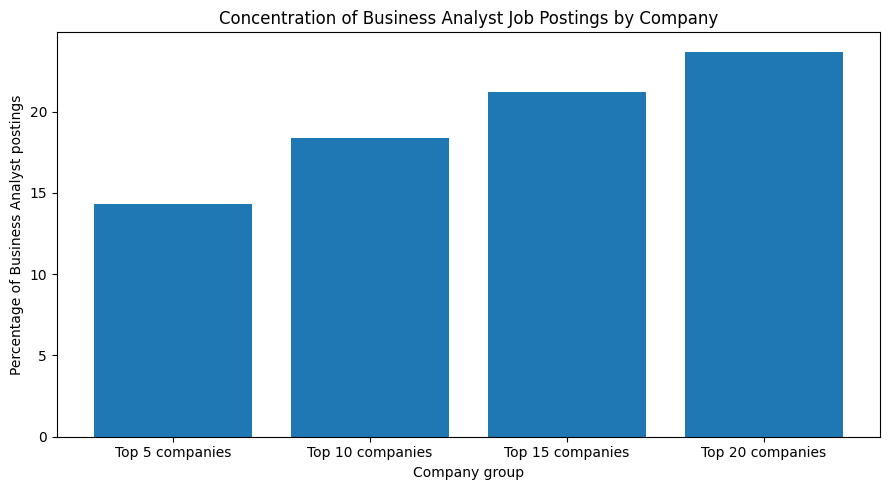

In [14]:
plt.figure(figsize=(9, 5))

plt.bar(
    company_concentration["Company group"],
    company_concentration["Percentage of all jobs"]
)

plt.xlabel("Company group")
plt.ylabel("Percentage of Business Analyst postings")
plt.title("Concentration of Business Analyst Job Postings by Company")

plt.tight_layout()
plt.show()

### **RQ2 Region based analysis**




In [15]:
# RQ2 — Country distribution

country_counts = (
    df["search_country"]
    .value_counts()
    .reset_index()
)

country_counts.columns = ["country", "job_count"]

# Add percentage
country_counts["percentage"] = (
    country_counts["job_count"] / len(df) * 100
)

display(country_counts)

,country,job_count,percentage
0,United States,3638,81.936937
1,United Kingdom,335,7.545045
2,Canada,246,5.540541
3,Australia,221,4.977477


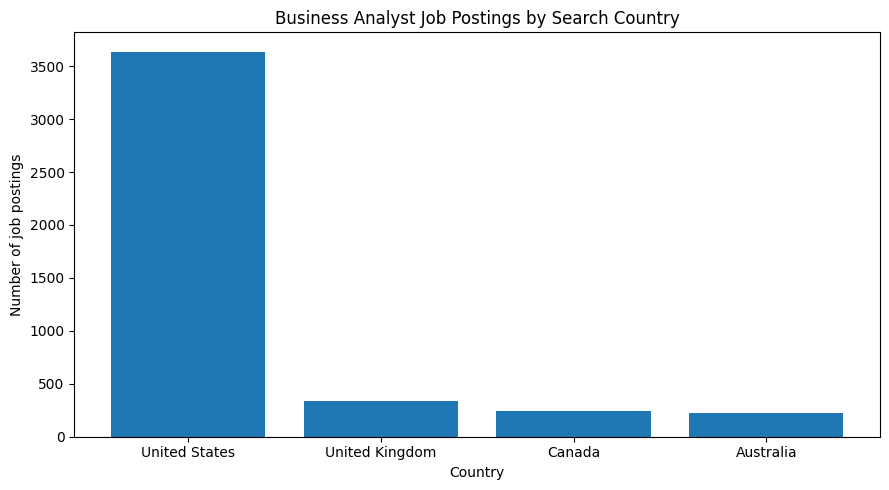

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    country_counts["country"],
    country_counts["job_count"]
)

plt.xlabel("Country")
plt.ylabel("Number of job postings")
plt.title("Business Analyst Job Postings by Search Country")

plt.tight_layout()
plt.show()

In [17]:
# RQ2 — Actual job locations

location_counts = (
    df["job_location"]
    .value_counts()
    .head(20)
    .reset_index()
)

location_counts.columns = ["job_location", "job_count"]

# Add percentage of all postings
location_counts["percentage"] = (
    location_counts["job_count"] / len(df) * 100
)

display(location_counts)

,job_location,job_count,percentage
0,"New York, NY",104,2.342342
1,"Atlanta, GA",81,1.824324
2,"Boston, MA",78,1.756757
3,"London, England, United Kingdom",66,1.486486
4,"Chicago, IL",64,1.441441
5,"Dallas, TX",55,1.238739
6,"Austin, TX",54,1.216216
7,"Richmond, VA",54,1.216216
8,"Washington, DC",53,1.193694
9,"Houston, TX",52,1.171171


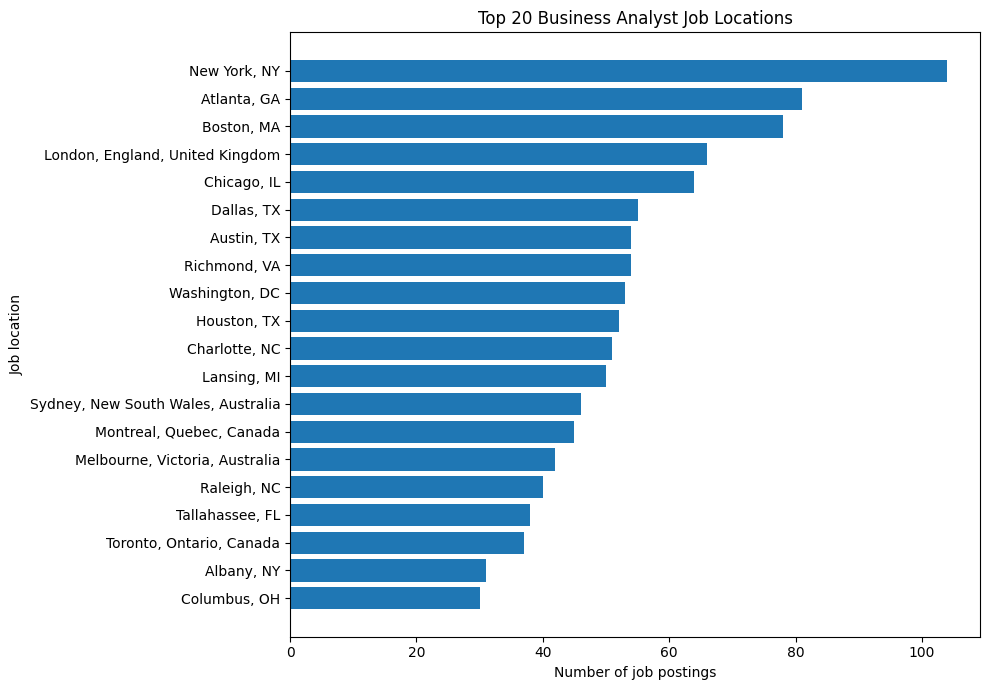

In [18]:
plt.figure(figsize=(10, 7))

plt.barh(
    location_counts["job_location"][::-1],
    location_counts["job_count"][::-1]
)

plt.xlabel("Number of job postings")
plt.ylabel("Job location")
plt.title("Top 20 Business Analyst Job Locations")

plt.tight_layout()
plt.show()

In [19]:
# RQ2 — Concentration of job postings by actual job location

location_all = df["job_location"].value_counts()

total_jobs = len(df)

top_5_locations = location_all.head(5).sum()
top_10_locations = location_all.head(10).sum()
top_15_locations = location_all.head(15).sum()
top_20_locations = location_all.head(20).sum()

location_concentration = pd.DataFrame({
    "Location group": [
        "Top 5 locations",
        "Top 10 locations",
        "Top 15 locations",
        "Top 20 locations"
    ],
    "Job postings": [
        top_5_locations,
        top_10_locations,
        top_15_locations,
        top_20_locations
    ],
    "Percentage of all jobs": [
        top_5_locations / total_jobs * 100,
        top_10_locations / total_jobs * 100,
        top_15_locations / total_jobs * 100,
        top_20_locations / total_jobs * 100
    ]
})

display(location_concentration)

,Location group,Job postings,Percentage of all jobs
0,Top 5 locations,393,8.851351
1,Top 10 locations,661,14.887387
2,Top 15 locations,895,20.157658
3,Top 20 locations,1071,24.121622


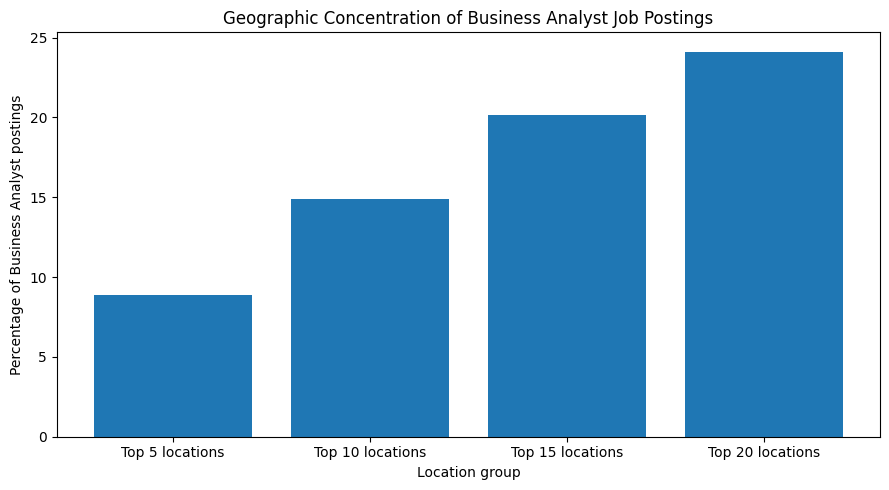

In [20]:
plt.figure(figsize=(9, 5))

plt.bar(
    location_concentration["Location group"],
    location_concentration["Percentage of all jobs"]
)

plt.xlabel("Location group")
plt.ylabel("Percentage of Business Analyst postings")
plt.title("Geographic Concentration of Business Analyst Job Postings")

plt.tight_layout()
plt.show()

### **RQ3 Analysis based on Skills**

In [21]:
# RQ3 — Split the job_skills field into individual skills

# Keep only the columns we need
skills_df = df[["job_link", "job_skills"]].copy()

# Split comma-separated skills into separate rows
skills_df["skill"] = skills_df["job_skills"].str.split(",")

skills_df = skills_df.explode("skill")

# Clean whitespace and standardise capitalisation
skills_df["skill"] = skills_df["skill"].str.strip()
skills_df["skill"] = skills_df["skill"].str.lower()

# Remove empty skill values
skills_df = skills_df[skills_df["skill"].notna() & (skills_df["skill"] != "")]

print("Original jobs:", len(df))
print("Skill records after splitting:", len(skills_df))
print("Unique skills:", skills_df["skill"].nunique())

display(skills_df.head(20))

Original jobs: 4440
Skill records after splitting: 111053
Unique skills: 26341


,job_link,job_skills,skill
0,https://www.linkedin.com/jobs/view/secret-clea...,"Microsoft Office 365, Microsoft Teams, SharePo...",microsoft office 365
0,https://www.linkedin.com/jobs/view/secret-clea...,"Microsoft Office 365, Microsoft Teams, SharePo...",microsoft teams
0,https://www.linkedin.com/jobs/view/secret-clea...,"Microsoft Office 365, Microsoft Teams, SharePo...",sharepoint online
0,https://www.linkedin.com/jobs/view/secret-clea...,"Microsoft Office 365, Microsoft Teams, SharePo...",sharepoint 2016/2019
0,https://www.linkedin.com/jobs/view/secret-clea...,"Microsoft Office 365, Microsoft Teams, SharePo...",microsoft powerpoint
0,https://www.linkedin.com/jobs/view/secret-clea...,"Microsoft Office 365, Microsoft Teams, SharePo...",project management
0,https://www.linkedin.com/jobs/view/secret-clea...,"Microsoft Office 365, Microsoft Teams, SharePo...",requirements gathering
0,https://www.linkedin.com/jobs/view/secret-clea...,"Microsoft Office 365, Microsoft Teams, SharePo...",customer engagement
0,https://www.linkedin.com/jobs/view/secret-clea...,"Microsoft Office 365, Microsoft Teams, SharePo...",documentation
0,https://www.linkedin.com/jobs/view/secret-clea...,"Microsoft Office 365, Microsoft Teams, SharePo...",dod secret security clearance


In [22]:
# RQ3 — Remove duplicate skill entries within each job

skills_clean = skills_df.copy()

# Remove duplicate skill entries for the same job
skills_clean = skills_clean.drop_duplicates(
    subset=["job_link", "skill"]
)

print("Skill records before removing duplicates:", len(skills_df))
print("Skill records after removing duplicates:", len(skills_clean))
print("Duplicate skill entries removed:", len(skills_df) - len(skills_clean))

print("\nUnique jobs:", skills_clean["job_link"].nunique())
print("Unique skills:", skills_clean["skill"].nunique())

display(skills_clean.head(20))

Skill records before removing duplicates: 111053
Skill records after removing duplicates: 110274
Duplicate skill entries removed: 779

Unique jobs: 4440
Unique skills: 26341


,job_link,job_skills,skill
0,https://www.linkedin.com/jobs/view/secret-clea...,"Microsoft Office 365, Microsoft Teams, SharePo...",microsoft office 365
0,https://www.linkedin.com/jobs/view/secret-clea...,"Microsoft Office 365, Microsoft Teams, SharePo...",microsoft teams
0,https://www.linkedin.com/jobs/view/secret-clea...,"Microsoft Office 365, Microsoft Teams, SharePo...",sharepoint online
0,https://www.linkedin.com/jobs/view/secret-clea...,"Microsoft Office 365, Microsoft Teams, SharePo...",sharepoint 2016/2019
0,https://www.linkedin.com/jobs/view/secret-clea...,"Microsoft Office 365, Microsoft Teams, SharePo...",microsoft powerpoint
0,https://www.linkedin.com/jobs/view/secret-clea...,"Microsoft Office 365, Microsoft Teams, SharePo...",project management
0,https://www.linkedin.com/jobs/view/secret-clea...,"Microsoft Office 365, Microsoft Teams, SharePo...",requirements gathering
0,https://www.linkedin.com/jobs/view/secret-clea...,"Microsoft Office 365, Microsoft Teams, SharePo...",customer engagement
0,https://www.linkedin.com/jobs/view/secret-clea...,"Microsoft Office 365, Microsoft Teams, SharePo...",documentation
0,https://www.linkedin.com/jobs/view/secret-clea...,"Microsoft Office 365, Microsoft Teams, SharePo...",dod secret security clearance


In [23]:
# RQ3 — Count how many jobs require each skill

skill_frequency = (
    skills_clean
    .groupby("skill")["job_link"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)

skill_frequency.columns = ["skill", "job_count"]

# Calculate percentage of Business Analyst jobs requiring each skill
skill_frequency["percentage_of_jobs"] = (
    skill_frequency["job_count"] / len(df) * 100
)

display(skill_frequency.head(30))

,skill,job_count,percentage_of_jobs
0,business analysis,1943,43.761261
1,project management,1507,33.941441
2,data analysis,1452,32.702703
3,communication,1350,30.405405
4,sql,1044,23.513514
5,analytical skills,902,20.315315
6,requirements gathering,776,17.477477
7,problem solving,763,17.184685
8,communication skills,740,16.666667
9,teamwork,664,14.954955


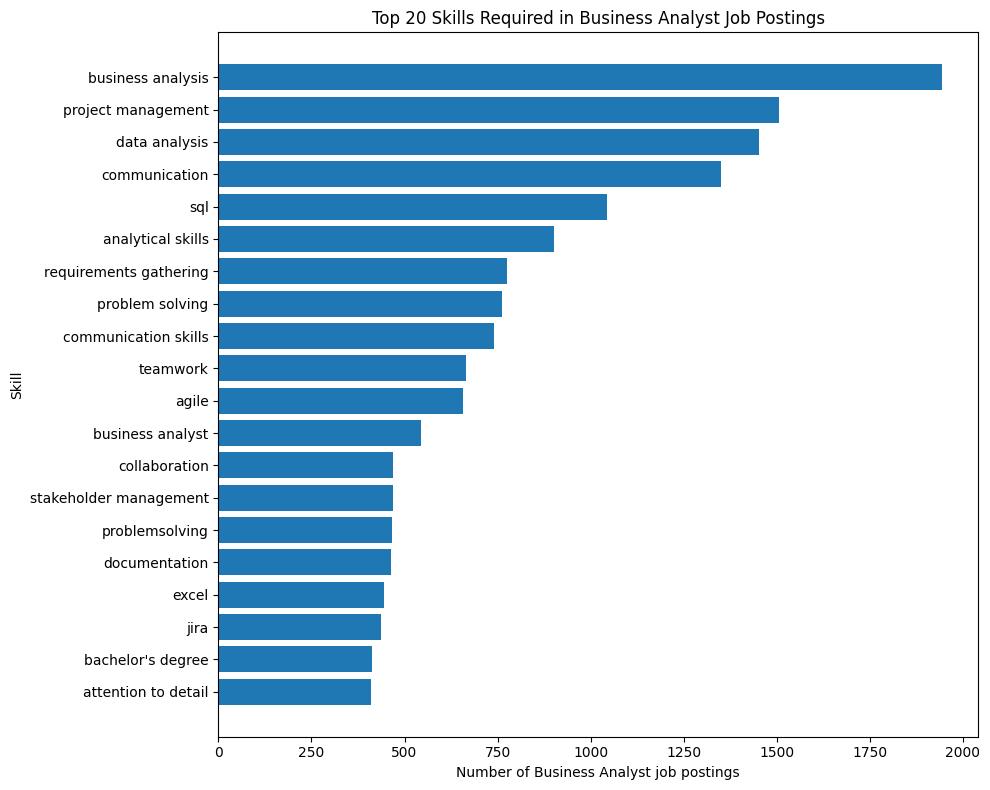

In [24]:
# Top 20 most frequently required skills

top_skills = skill_frequency.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_skills["skill"][::-1],
    top_skills["job_count"][::-1]
)

plt.xlabel("Number of Business Analyst job postings")
plt.ylabel("Skill")
plt.title("Top 20 Skills Required in Business Analyst Job Postings")

plt.tight_layout()
plt.show()

In [25]:
# Inspect the top 50 skills

display(skill_frequency.head(50))

,skill,job_count,percentage_of_jobs
0,business analysis,1943,43.761261
1,project management,1507,33.941441
2,data analysis,1452,32.702703
3,communication,1350,30.405405
4,sql,1044,23.513514
5,analytical skills,902,20.315315
6,requirements gathering,776,17.477477
7,problem solving,763,17.184685
8,communication skills,740,16.666667
9,teamwork,664,14.954955


In [26]:
# RQ3 — Standardise obvious duplicate/variant skill names

skill_standardisation = {
    "problemsolving": "problem solving",
    "problemsolving skills": "problem solving",
    "communication skills": "communication"
}

skills_clean["skill_standardised"] = skills_clean["skill"].replace(
    skill_standardisation
)

# Count unique jobs requiring each standardised skill
skill_frequency_clean = (
    skills_clean
    .groupby("skill_standardised")["job_link"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)

skill_frequency_clean.columns = ["skill", "job_count"]

skill_frequency_clean["percentage_of_jobs"] = (
    skill_frequency_clean["job_count"] / len(df) * 100
)

display(skill_frequency_clean.head(30))

,skill,job_count,percentage_of_jobs
0,communication,2069,46.599099
1,business analysis,1943,43.761261
2,problem solving,1511,34.031532
3,project management,1507,33.941441
4,data analysis,1452,32.702703
5,sql,1044,23.513514
6,analytical skills,902,20.315315
7,requirements gathering,776,17.477477
8,teamwork,664,14.954955
9,agile,657,14.797297


In [27]:
# RQ3 — Distribution of the number of skills per job

skills_per_job = (
    skills_clean
    .groupby("job_link")["skill_standardised"]
    .nunique()
)

print("Average skills per job:", skills_per_job.mean())
print("Median skills per job:", skills_per_job.median())
print("Minimum skills per job:", skills_per_job.min())
print("Maximum skills per job:", skills_per_job.max())

print("\nSkill-count summary:")
display(skills_per_job.describe())

Average skills per job: 24.829954954954953
Median skills per job: 21.0
Minimum skills per job: 1
Maximum skills per job: 159

Skill-count summary:


,skill_standardised
count,4440.000000
mean,24.829955
std,14.879577
min,1.000000
25%,16.000000
50%,21.000000
75%,29.000000
max,159.000000


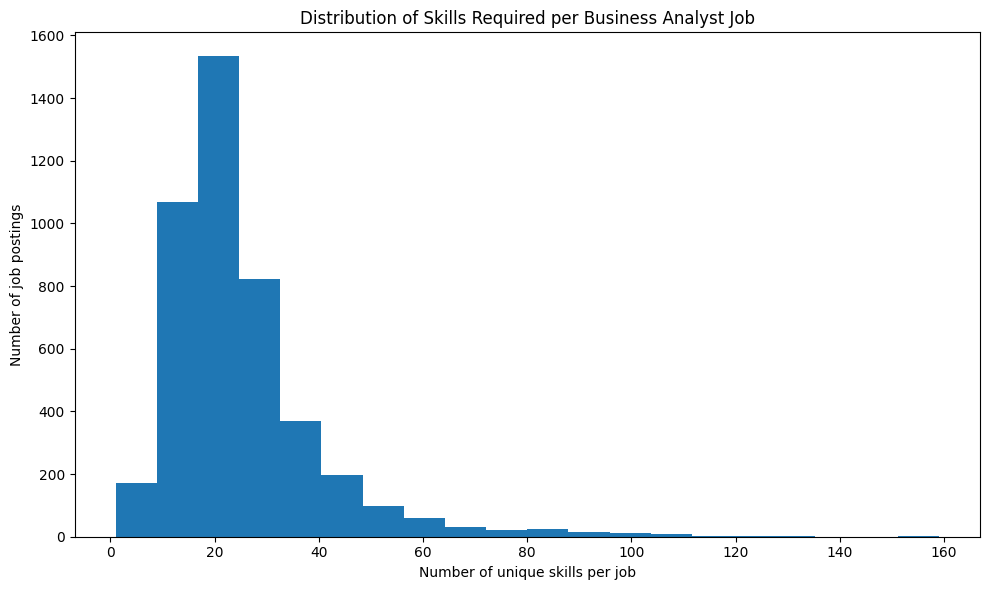

In [28]:
# Distribution of skills per Business Analyst job

plt.figure(figsize=(10, 6))

plt.hist(
    skills_per_job,
    bins=20
)

plt.xlabel("Number of unique skills per job")
plt.ylabel("Number of job postings")
plt.title("Distribution of Skills Required per Business Analyst Job")

plt.tight_layout()
plt.show()

**Interpret the Skills Findings**

In [29]:
top_5_skills = skill_frequency_clean.head(5)

print("Top 5 skills:")
display(top_5_skills)

print(
    "\nAverage percentage of jobs covered by the top 5 skills:",
    top_5_skills["percentage_of_jobs"].mean()
)

Top 5 skills:


,skill,job_count,percentage_of_jobs
0,communication,2069,46.599099
1,business analysis,1943,43.761261
2,problem solving,1511,34.031532
3,project management,1507,33.941441
4,data analysis,1452,32.702703



Average percentage of jobs covered by the top 5 skills: 38.20720720720721
